In [1]:
!rm -rf /kaggle/working/train

In [16]:
!rm -rf /kaggle/working/speech-classification-deep-learning/trained_models

In [1]:
!7z x /kaggle/input/competitions/tensorflow-speech-recognition-challenge/train.7z -o/kaggle/working/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,4 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /kaggle/input/competitions/tensorflow-speech-recognition-challenge                                                                            1 file, 1121103842 bytes (1070 MiB)

Extracting archive: /kaggle/input/competitions/tensorflow-speech-recognition-challenge/train.7z
--
Path = /kaggle/input/competitions/tensorflow-speech-recognition-challenge/train.7z
Type = 7z
Physical Size = 1121103842
Headers Size = 389133
Method = Delta LZMA2:24
Solid = +
Blocks = 2

      0% 38 - train/audio/_background_noise_/doing_the_dishes.wa                                                              0% 40 - train/audio/_background_noise_/exercise_bike.w                                                          0% 42 - train/audio/_background_noise_/running_tap.w   

In [2]:
import os
os.chdir('/kaggle/working')

In [3]:
!git clone https://github.com/basiaseweryn/speech-classification-deep-learning

Cloning into 'speech-classification-deep-learning'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 61 (delta 33), reused 51 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 10.36 KiB | 378.00 KiB/s, done.
Resolving deltas: 100% (33/33), done.


In [26]:
!git pull

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 397 bytes | 397.00 KiB/s, done.
From https://github.com/basiaseweryn/speech-classification-deep-learning
   f874005..1a02711  main       -> origin/main
Updating f874005..1a02711
Fast-forward
 utils/models.py | 9 +++++++--
 1 file changed, 7 insertions(+), 2 deletions(-)


In [18]:
%cd /kaggle/working/speech-classification-deep-learning

/kaggle/working/speech-classification-deep-learning


In [ ]:
import sys
import os

PROJECT_ROOT = "/kaggle/working/speech-classification-deep-learning"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


UTILS_PATH = os.path.join(PROJECT_ROOT, "utils")
if UTILS_PATH not in sys.path:
    sys.path.insert(0, UTILS_PATH)

print(f"project root added: {PROJECT_ROOT}")
print(f"utils folder added: {UTILS_PATH}")
print(f"available files: {os.listdir(PROJECT_ROOT)}")

project root added: /kaggle/working/speech-classification-deep-learning
utils folder added: /kaggle/working/speech-classification-deep-learning/utils
available files: ['LICENSE', 'utils', 'README.md', '.git']


In [ ]:
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

import config
import models
import data_utils
import evaluation_utils


importlib.reload(config)
importlib.reload(models)
importlib.reload(data_utils)
importlib.reload(evaluation_utils)


from config import seed, experiments, trained_models_dir
from data_utils import get_dataloaders
from models import get_model
from evaluation_utils import plot_confusion_matrix, plot_learning_curves

def seed_everything(s=seed):
    random.seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
# print(f"environment ready. active classes: {active_classes}")

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    
    pbar = tqdm(loader, unit="batch", leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        all_preds.extend(predicted.cpu().tolist())
        all_targets.extend(targets.cpu().tolist())
        pbar.set_postfix(loss=f"{running_loss/(pbar.n+1):.4f}", acc=f"{100.*correct/total:.2f}%")
        
    epoch_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    return running_loss / len(loader), 100. * correct / total, epoch_f1, all_targets, all_preds










def validate_model(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            all_preds.extend(predicted.cpu().tolist())
            all_targets.extend(targets.cpu().tolist())

    epoch_acc = 100. * correct / total
    epoch_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    # return loss, accuracy, f1, all targets and predictions for confusion matrix
    return running_loss / len(loader), epoch_acc, epoch_f1, all_targets, all_preds










import itertools
import copy

import itertools
import copy
import time
from sklearn.metrics import f1_score, confusion_matrix

def generate_combinations(config):
    top_keys = [k for k, v in config.items() if isinstance(v, list) and k != 'model_params']
    model_keys = [k for k, v in config['model_params'].items() if isinstance(v, list)]
    
    top_values = [config[k] if k in top_keys else [config[k]] for k in top_keys]
    model_values = [config['model_params'][k] if k in model_keys else [config['model_params'][k]] for k in model_keys]
    
    combinations = []
    for top_comb in itertools.product(*top_values):
        for model_comb in itertools.product(*model_values):
            new_config = copy.deepcopy(config)
            
            for i, k in enumerate(top_keys): new_config[k] = top_comb[i]
            for i, k in enumerate(model_keys): new_config['model_params'][k] = model_comb[i]
            
            type_map = {
                "BaselineCNN": "cnn",
                "TransformerScratch": "transformer",
                "PretrainedTransformer": "pretrained_trans"
            }

            base_name = type_map.get(new_config['model_type'], "model")

            task = new_config.get("task_type", "standard")
            if task != "standard":
                base_name = f"{base_name}_{task}"
            
            suffix = ""
            for i, k in enumerate(top_keys): suffix += f"_{k}_{top_comb[i]}"
            for i, k in enumerate(model_keys): suffix += f"_{k}_{model_comb[i]}"
            
            model_filename = f"{base_name}{suffix}"
            combinations.append((new_config, model_filename))
            
    return combinations

def run_experiment(exp_name, num_workers=4, n_already_trained=0):
    seed_everything()
    original_config = experiments[exp_name]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    exp_dir = os.path.join(trained_models_dir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)

    all_runs = generate_combinations(original_config)
    total_runs = len(all_runs)

    if n_already_trained > 0:
        print(f"Pomijam pierwsze {n_already_trained} modeli. Rozpoczynam od modelu nr {n_already_trained + 1}...")
    

    runs_to_execute = all_runs[n_already_trained:]
    results = {}

    for i, (config, model_filename) in enumerate(runs_to_execute):
        current_idx = n_already_trained + i + 1
        
        print(f"\n{'='*40}")
        print(f"MODEL {current_idx} z {total_runs}: {model_filename}")
        print(f"{'='*40}")

        train_loader, val_loader = get_dataloaders(config, num_workers=num_workers)
        model = get_model(config).to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=config["lr"])
        
        scheduler_type = config.get("scheduler")
        if scheduler_type == "ReduceLROnPlateau":
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        elif scheduler_type == "CosineAnnealingLR":
            scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
        else: scheduler = None

        history = {
            'train_loss': [], 'train_acc': [], 'train_f1': [],
            'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_cm': [], 'lr': []
        }

        for epoch in range(config["epochs"]):
            start_time = time.time()
            t_loss, t_acc, t_f1, _, _ = train_one_epoch(model, train_loader, criterion, optimizer, device)
            v_loss, v_acc, v_f1, v_targets, v_preds = validate_model(model, val_loader, criterion, device)
            
            curr_lr = optimizer.param_groups[0]['lr']
            if scheduler:
                if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau): scheduler.step(v_loss)
                else: scheduler.step()

            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['val_loss'].append(v_loss)
            history['val_acc'].append(v_acc)
            history['val_f1'].append(v_f1)
            history['val_cm'].append(confusion_matrix(v_targets, v_preds))
            history['lr'].append(curr_lr)

            epoch_time = time.time() - start_time
            print(f"epoch {epoch+1}/{config['epochs']} [{epoch_time:.1f}s] | "
                  f"train acc: {t_acc:.2f}% | val acc: {v_acc:.2f}% f1: {v_f1:.4f} | lr: {curr_lr:.6f}")

        save_path = os.path.join(exp_dir, f"{model_filename}.pth")
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': config,
            'history': history
        }, save_path)
        print(f"✅ Zapisano: {model_filename}.pth")
        results[model_filename] = history

    return results

In [31]:
history3 = run_experiment("stage_1_baseline_transformer_pretrained")

saving locally: ./trained_models

starting experiment: stage_1_baseline_transformer_pretrained


epoch 1/25 [17.8s] | train loss: 0.7450 acc: 69.43% | val loss: 0.5119 acc: 80.14% f1: 0.7928 | lr: 0.000500


epoch 2/25 [17.7s] | train loss: 0.3600 acc: 86.51% | val loss: 0.3315 acc: 87.57% f1: 0.8754 | lr: 0.000500


epoch 3/25 [17.9s] | train loss: 0.2355 acc: 91.55% | val loss: 0.3773 acc: 87.14% f1: 0.8715 | lr: 0.000500


epoch 4/25 [17.8s] | train loss: 0.1752 acc: 93.65% | val loss: 0.3666 acc: 88.15% f1: 0.8807 | lr: 0.000500


...

epoch 21/25 [17.8s] | train loss: 0.0002 acc: 100.00% | val loss: 0.3908 acc: 92.20% f1: 0.9220 | lr: 0.000063


epoch 22/25 [17.7s] | train loss: 0.0002 acc: 100.00% | val loss: 0.3961 acc: 92.15% f1: 0.9215 | lr: 0.000063


epoch 23/25 [17.7s] | train loss: 0.0001 acc: 100.00% | val loss: 0.3986 acc: 92.10% f1: 0.9210 | lr: 0.000031


epoch 24/25 [17.6s] | train loss: 0.0001 acc: 100.00% | val loss: 0.4013 acc: 92.26% f1: 0.9225 | lr: 0.000031


epoch 25/25 [17.8s] | train loss: 0.0001 acc: 100.00% | val loss: 0.4040 acc: 92.41% f1: 0.9241 | lr: 0.000031
experiment finished. model and history saved to: ./trained_models/stage_1_baseline_transformer_pretrained/final_model.pth



In [24]:
history2 = run_experiment("stage_1_baseline_transformer_scratch")

saving locally: ./trained_models

starting experiment: stage_1_baseline_transformer_scratch


epoch 1/25 [16.6s] | train loss: 1.2288 acc: 40.88% | val loss: 1.1947 acc: 45.94% f1: 0.4284 | lr: 0.000500


epoch 2/25 [16.6s] | train loss: 0.8928 acc: 61.41% | val loss: 0.7748 acc: 67.86% f1: 0.6815 | lr: 0.000500


epoch 3/25 [16.6s] | train loss: 0.6581 acc: 72.84% | val loss: 0.6791 acc: 73.81% f1: 0.7393 | lr: 0.000500


epoch 4/25 [16.7s] | train loss: 0.5598 acc: 77.45% | val loss: 0.5737 acc: 77.56% f1: 0.7777 | lr: 0.000500


...

epoch 21/25 [16.6s] | train loss: 0.0364 acc: 98.80% | val loss: 0.5799 acc: 85.99% f1: 0.8602 | lr: 0.000125


epoch 22/25 [16.7s] | train loss: 0.0156 acc: 99.47% | val loss: 0.6270 acc: 86.20% f1: 0.8619 | lr: 0.000125


epoch 23/25 [16.5s] | train loss: 0.0126 acc: 99.55% | val loss: 0.6538 acc: 86.30% f1: 0.8633 | lr: 0.000125


epoch 24/25 [16.6s] | train loss: 0.0116 acc: 99.59% | val loss: 0.6828 acc: 86.46% f1: 0.8640 | lr: 0.000125


epoch 25/25 [17.1s] | train loss: 0.0097 acc: 99.60% | val loss: 0.6988 acc: 86.20% f1: 0.8622 | lr: 0.000063
experiment finished. model and history saved to: ./trained_models/stage_1_baseline_transformer_scratch/final_model.pth



In [23]:
history = run_experiment("stage_1_baseline_cnn")

saving locally: ./trained_models

starting experiment: stage_1_baseline_cnn


epoch 1/25 [15.8s] | train loss: 1.1229 acc: 51.69% | val loss: 0.9454 acc: 56.43% f1: 0.5186 | lr: 0.000500


epoch 2/25 [15.7s] | train loss: 0.6899 acc: 73.58% | val loss: 0.6025 acc: 78.08% f1: 0.7791 | lr: 0.000500


epoch 3/25 [15.5s] | train loss: 0.5378 acc: 79.94% | val loss: 0.4628 acc: 84.19% f1: 0.8420 | lr: 0.000500


epoch 4/25 [15.8s] | train loss: 0.4229 acc: 84.88% | val loss: 0.4217 acc: 85.41% f1: 0.8541 | lr: 0.000500


...

epoch 21/25 [15.8s] | train loss: 0.1067 acc: 96.31% | val loss: 0.1692 acc: 93.89% f1: 0.9385 | lr: 0.000500


epoch 22/25 [15.7s] | train loss: 0.0996 acc: 96.42% | val loss: 0.2542 acc: 90.57% f1: 0.9037 | lr: 0.000500


epoch 23/25 [15.8s] | train loss: 0.1000 acc: 96.38% | val loss: 0.1708 acc: 93.47% f1: 0.9354 | lr: 0.000500


epoch 24/25 [15.8s] | train loss: 0.0685 acc: 97.76% | val loss: 0.1280 acc: 95.21% f1: 0.9520 | lr: 0.000250


epoch 25/25 [15.7s] | train loss: 0.0641 acc: 97.73% | val loss: 0.1296 acc: 95.31% f1: 0.9531 | lr: 0.000250
experiment finished. model and history saved to: ./trained_models/stage_1_baseline_cnn/final_model.pth



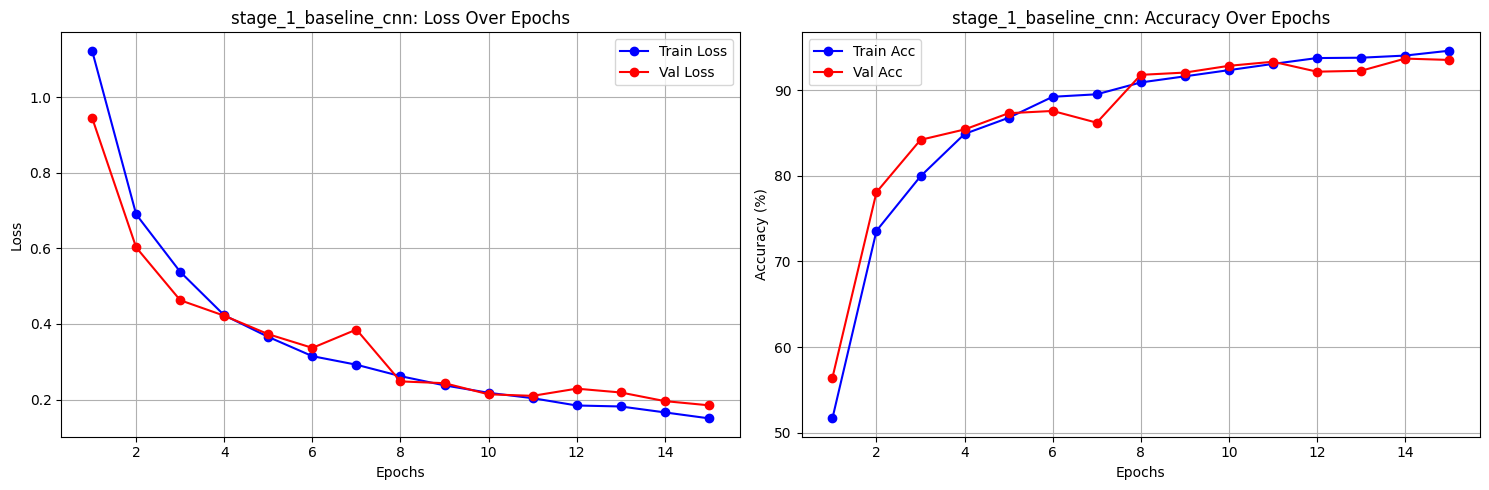

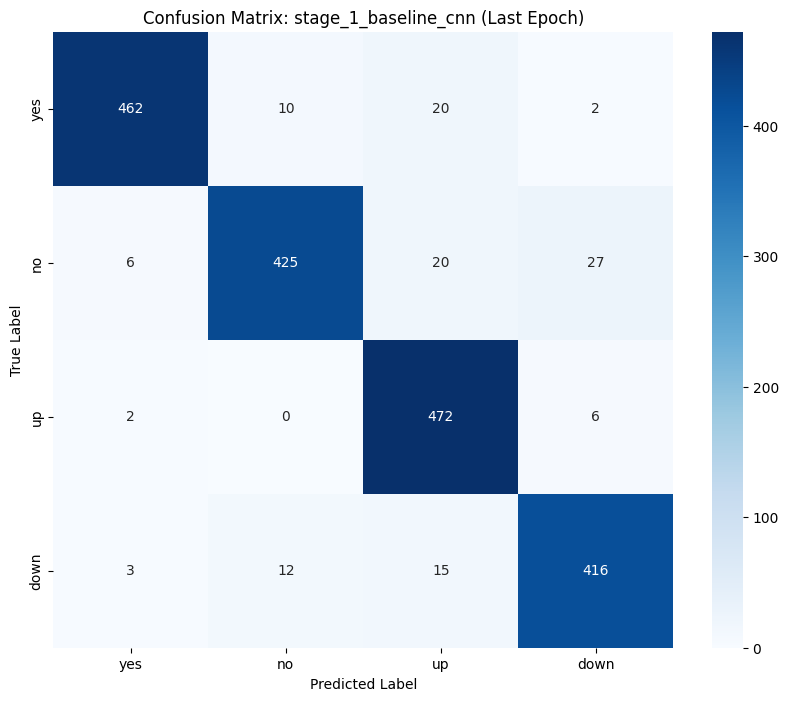

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from config import SUBSET_CLASSES, ALL_CLASSES, experiments

def show_history_plots(history, exp_name):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    plt.title(f'{exp_name}: Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
    plt.title(f'{exp_name}: Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

    reduced = experiments[exp_name].get("reduced_classes", False)
    classes = SUBSET_CLASSES if reduced else ALL_CLASSES
    
    last_cm = history['val_cm'][-1]

    plt.figure(figsize=(10, 8))
    sns.heatmap(last_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {exp_name} (Last Epoch)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
show_history_plots(history, "stage_1_baseline_cnn")

In [18]:
history2 = run_experiment("stage_2_transformer_scratch_default")

saving locally: ./trained_models

starting experiment: stage_2_transformer_scratch_default


epoch 1/20 [160.5s] | train loss: 1.3049 acc: 64.44% | val loss: 1.0345 acc: 67.71% f1: 0.6014 | lr: 0.000500


epoch 2/20 [158.4s] | train loss: 0.9374 acc: 70.13% | val loss: 0.8088 acc: 73.50% f1: 0.7098 | lr: 0.000497


epoch 3/20 [159.2s] | train loss: 0.7319 acc: 75.91% | val loss: 0.6610 acc: 78.74% f1: 0.7681 | lr: 0.000488


epoch 4/20 [160.5s] | train loss: 0.6057 acc: 80.02% | val loss: 0.5578 acc: 81.54% f1: 0.8024 | lr: 0.000473


epoch 5/20 [161.7s] | train loss: 0.5061 acc: 83.21% | val loss: 0.4929 acc: 84.31% f1: 0.8375 | lr: 0.000452
experiment finished. model and history saved to: ./trained_models/stage_2_transformer_scratch_default/final_model.pth



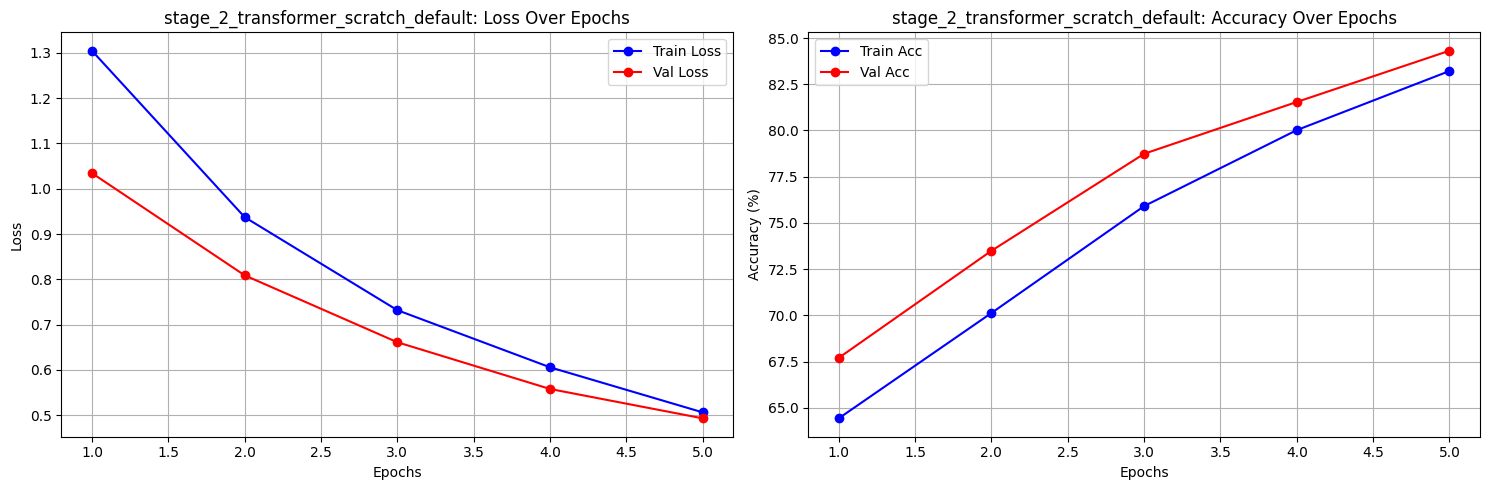

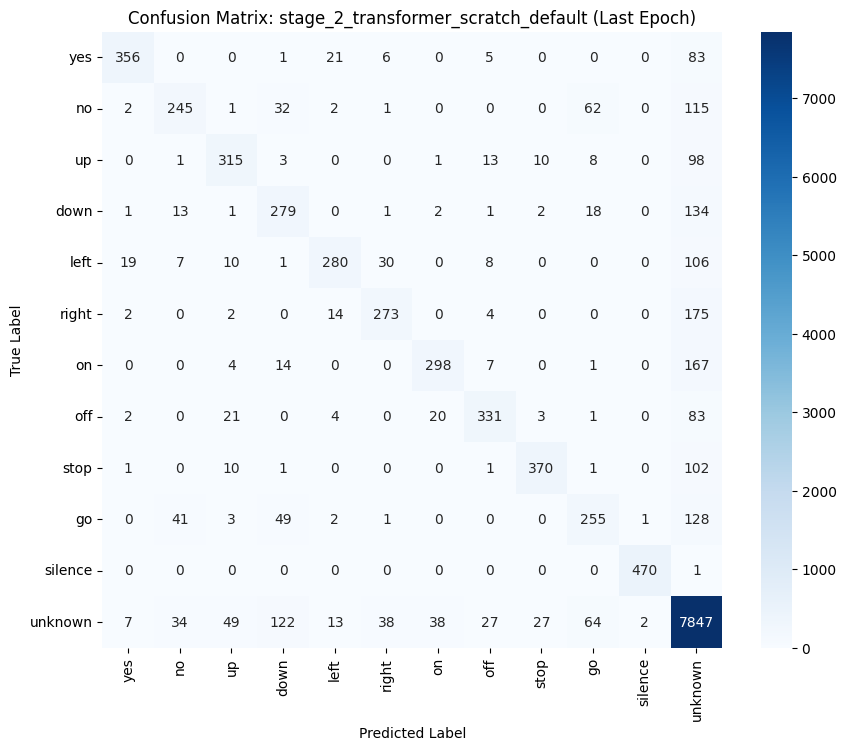

In [20]:
show_history_plots(history2, "stage_2_transformer_scratch_default")